In [6]:
import sys

import matplotlib.pyplot as plt
import xarray as xr

sys.path.append('../src')
import weather_utils

In [ ]:
fresh_pull = False
if fresh_pull:
    weather_array = weather_utils.pull_era5_reanalysis(
        lat_range=(30.0, 50.0),
        lon_range=(-120.0, -70.0),
        start_date='2025-11-01',
        end_date='2025-11-02',
        variables=[
            '2m_temperature',
            'total_precipitation'
            ],
        output_file='../resources/weather_data.nc'
    )
else:
    weather_array = xr.open_dataset('../resources/weather_data_extracted.nc')

2025-11-26 21:48:53,618 INFO Request ID is 40509fc7-2f32-4997-bc57-e6e0d3000a24
2025-11-26 21:48:53,858 INFO status has been updated to accepted
2025-11-26 21:48:53,858 INFO status has been updated to accepted
2025-11-26 21:49:08,641 INFO status has been updated to running
2025-11-26 21:49:08,641 INFO status has been updated to running
2025-11-26 21:49:28,289 INFO status has been updated to successful
2025-11-26 21:49:28,289 INFO status has been updated to successful
                                                                                       

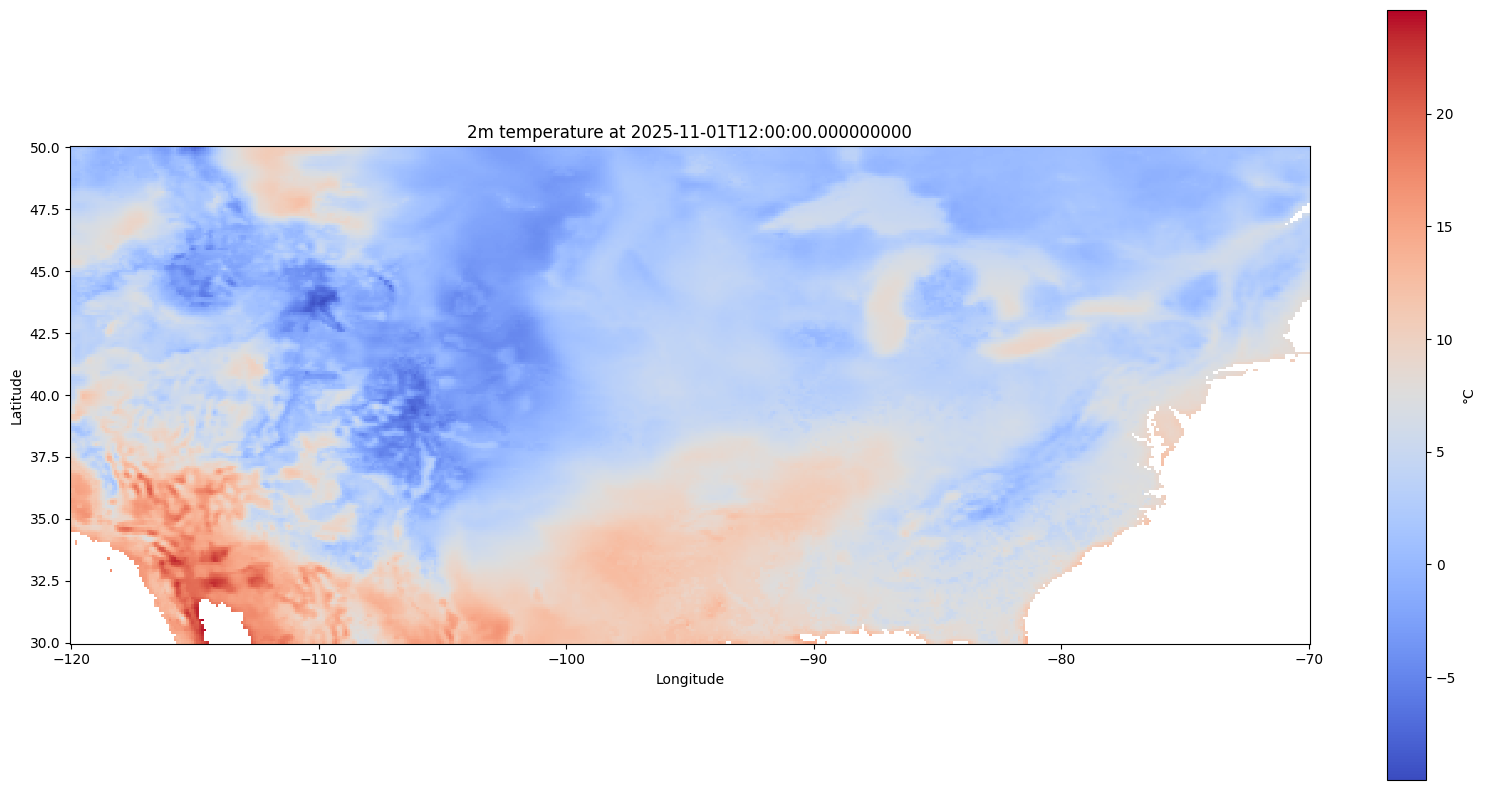

In [20]:
# choose a time index (0 = first available valid_time)
time_idx = 0
time = weather_array.valid_time.values[time_idx]

# extract 2m temperature (variable name in the dataset is "t2m")
t2m = weather_array["t2m"].isel(valid_time=time_idx)

# convert to Celsius if values look like Kelvin
if t2m.mean().item() > 200:
    t2m_plot = t2m - 273.15
    units = "°C"
else:
    t2m_plot = t2m
    units = weather_array["t2m"].attrs.get("units", "")

lon = weather_array.longitude
lat = weather_array.latitude

plt.figure(figsize=(20, 10))
pcm = plt.pcolormesh(lon, lat, t2m_plot, shading="auto", cmap="coolwarm")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"2m temperature at {str(time)}")
plt.colorbar(pcm, label=units)
plt.gca().set_aspect("equal", adjustable="box")
plt.show()